1. Hartmann 3D

In [2]:
from master_utils.benchmarks import hartmann
from ConfigSpace import Configuration,ConfigurationSpace,Float
from smac import Scenario
from smac import HyperparameterOptimizationFacade as HPOFacade

cs = ConfigurationSpace()

cs.add(
Float("x1",(0,1)),
    Float("x2",(0,1)),
    Float("x3",(0,1))
)

def eval(config:Configuration, seed:int):
    return hartmann([config["x1"],config["x2"],config["x3"]],3)

sc = Scenario(
    configspace = cs,
    name = "hartmann_3D",
    deterministic = True,
    n_trials = 300
)

smac = HPOFacade(
    scenario=sc,
    target_function=eval,
    #overwrite= True
)

incumbent = smac.optimize()
incumbent_cost = smac.runhistory.get_cost(incumbent)
print(incumbent)
print(incumbent_cost)

[INFO][abstract_initial_design.py:143] Using 30 initial design configurations and 0 additional configurations.
[INFO][smbo.py:523] Continuing from previous run.
[INFO][smbo.py:280] Optimization process was already finished. Returning incumbent...
Configuration(values={
  'x1': 0.1120891186802,
  'x2': 0.5512170343042,
  'x3': 0.8523208816276,
})
-3.862088535630321


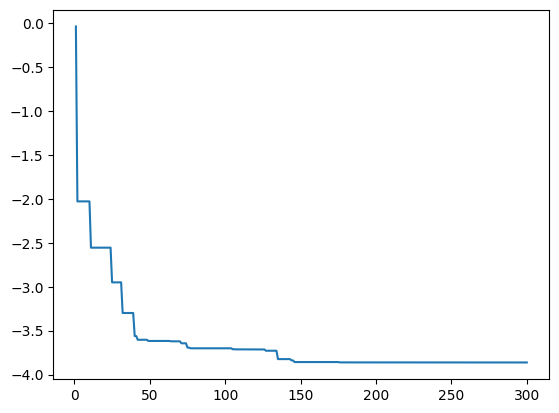

In [3]:
import matplotlib.pyplot as plt
import numpy as np

rh = smac.runhistory
trials=[]

for key, value in rh.items():
    trials.append({
        "starttime": value.starttime,
        "cost": value.cost,
    })
trials = sorted(trials, key= lambda x: x["starttime"])
costs = np.array([trial["cost"] for trial in trials])
iterations = np.arange(1, len(costs) + 1)

best_so_far = np.minimum.accumulate(costs)

fig,ax = plt.subplots()
ax.plot(iterations, best_so_far)

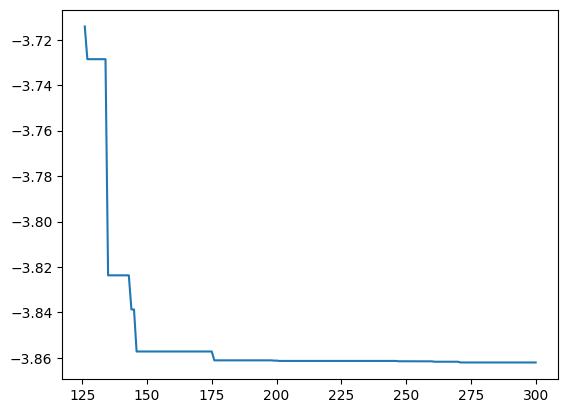

In [4]:
fig,ax = plt.subplots()
ax.plot(iterations[125:], best_so_far[125:])

In [5]:
configs = rh.get_configs()
origins = [config.origin for config in configs]

from collections import Counter
counts = Counter(origins)

print(counts)

Counter({'Acquisition Function Maximizer: Local Search': 215, 'Random Search': 55, 'Initial Design: Sobol': 30})


In [6]:
for k,v in cs.items():
    print(k,v)

x1 x1, Type: UniformFloat, Range: [0.0, 1.0], Default: 0.5
x2 x2, Type: UniformFloat, Range: [0.0, 1.0], Default: 0.5
x3 x3, Type: UniformFloat, Range: [0.0, 1.0], Default: 0.5


2. Hartmann 6D

In [7]:
cs = ConfigurationSpace()

cs.add(
    [Float(f"x{i}",(0,1)) for i in range(1,7)]
)

def eval(config:Configuration, seed:int):
    return hartmann([config[x] for x in cs.keys()], len(cs.keys()))

sc = Scenario(
    configspace = cs,
    name = "hartmann_6D",
    deterministic = True,
    n_trials = 300
)

smac = HPOFacade(
    scenario=sc,
    target_function=eval,
    #overwrite= True
)

incumbent = smac.optimize()
incumbent_cost = smac.runhistory.get_cost(incumbent)
print(incumbent)
print(incumbent_cost)

[INFO][abstract_initial_design.py:143] Using 60 initial design configurations and 0 additional configurations.
[INFO][smbo.py:523] Continuing from previous run.


[INFO][smbo.py:280] Optimization process was already finished. Returning incumbent...
Configuration(values={
  'x1': 0.4089172444279,
  'x2': 0.9895865949181,
  'x3': 0.7697815516376,
  'x4': 0.574596314837,
  'x5': 0.2632779277268,
  'x6': 0.0369787917954,
})
-2.9151072644322924


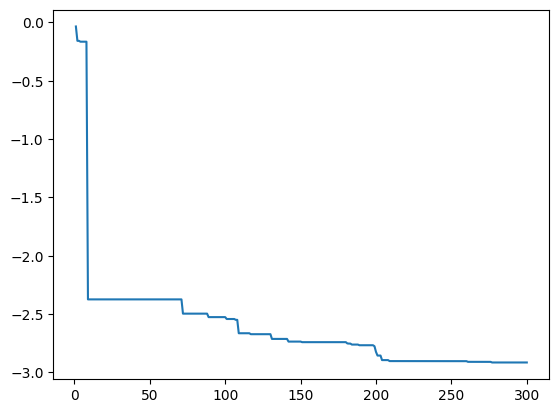

In [8]:
rh = smac.runhistory
trials=[]

for key, value in rh.items():
    trials.append({
        "starttime": value.starttime,
        "cost": value.cost,
    })
trials = sorted(trials, key= lambda x: x["starttime"])
costs = np.array([trial["cost"] for trial in trials])
iterations = np.arange(1, len(costs) + 1)

best_so_far = np.minimum.accumulate(costs)

fig,ax = plt.subplots()
ax.plot(iterations, best_so_far)

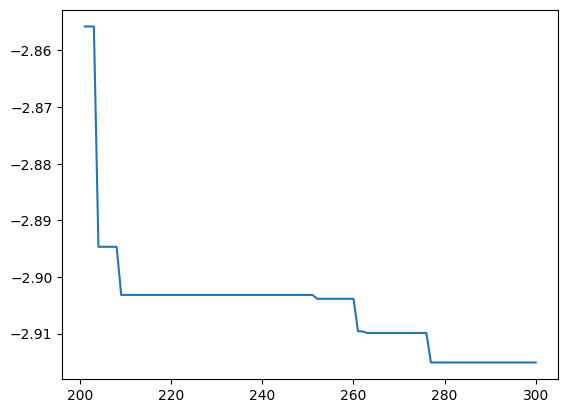

In [11]:
fig,ax = plt.subplots()
ax.plot(iterations[200:], best_so_far[200:])

In [10]:
configs = rh.get_configs()
origins = [config.origin for config in configs]

from collections import Counter
counts = Counter(origins)

print(counts)

Counter({'Acquisition Function Maximizer: Local Search': 193, 'Initial Design: Sobol': 60, 'Random Search': 47})
